# Classificação de tumores com SVM
## Breast Cancer Wisconsin (Diagnostic)

O objetivo desta atividade é analisar dados de tumores e treinar modelos de Support Vector Machine (SVM) para classificar cada caso como **benigno (B)** ou **maligno (M)**. Portanto, estamos trabalhando com classificação binária.

O Breast Cancer Wisconsin (Diagnostic) reúne medidas dos núcleos celulares obtidas a partir de imagens de biópsias por aspiração com agulha fina. As características incluem raio, textura, perímetro, área e outras medidas. Para cada uma das dez características básicas, há medidas de média, erro padrão e dos maiores valores, totalizando 30 atributos numéricos.

Vou explorar a base, fazer a limpeza, separar treino e teste e comparar os kernels linear e RBF. Os parâmetros serão escolhidos usando apenas validação cruzada no treinamento. O teste ficará reservado para a avaliação final.

**Fonte dos dados:** [Breast Cancer Wisconsin (Diagnostic) — Kaggle, uciml](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data).

## 1. Bibliotecas
Usarei pandas para as tabelas, matplotlib e seaborn para os gráficos e scikit-learn para o pré-processamento, SVM e avaliação. O único algoritmo de classificação utilizado será o SVM.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 35)
print("Versões: pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

Versões: pandas 2.2.3 | scikit-learn 1.8.0


## 2. Carregamento dos dados
No Kaggle, adicione a base **uciml/breast-cancer-wisconsin-data** pelo botão **Add Input / Add Data**. A célula abaixo procura o `data.csv` dessa base dentro de `/kaggle/input`. Fora do Kaggle, ela também aceita o CSV original dentro da pasta `dataset` ou ao lado do notebook.

A fonte é o arquivo CSV do Kaggle. Não utilizo `load_breast_cancer()`.

In [2]:
arquivos = list(Path("/kaggle/input").glob("**/breast-cancer-wisconsin-data/data.csv"))
if not arquivos:
    arquivos = [p for p in [Path("dataset/data.csv"), Path("data.csv")] if p.exists()]
if not arquivos:
    raise FileNotFoundError("Adicione o dataset uciml/breast-cancer-wisconsin-data ao notebook.")
caminho = arquivos[0]
dados = pd.read_csv(caminho)
print("Arquivo carregado:", caminho)
display(dados.head())

Arquivo carregado: dataset/data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Análise exploratória
### Estrutura, tipos, estatísticas e valores ausentes
Primeiro vou verificar o tamanho da base, os tipos das colunas e as estatísticas. Isso ajuda a perceber diferenças de escala e possíveis problemas de preenchimento. Esta exploração é descritiva: não vou selecionar atributos nem mudar a grade de parâmetros com base no teste.

In [3]:
print("Dimensões (linhas, colunas):", dados.shape)
print("\nTipos das colunas:")
display(dados.dtypes.to_frame("Tipo"))
print("\nInformações gerais:")
dados.info()
print("\nEstatísticas descritivas:")
display(dados.describe().T)
print("\nValores ausentes por coluna:")
display(dados.isna().sum().to_frame("Ausentes"))
print("Linhas completamente duplicadas:", dados.duplicated().sum())

Dimensões (linhas, colunas): (569, 33)

Tipos das colunas:

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  

,Tipo
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


,Ausentes
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [4]:
vazias = dados.columns[dados.isna().all()].tolist()
display(Markdown(
    f"A base tem **{dados.shape[0]} registros e {dados.shape[1]} colunas**. "
    f"As colunas completamente vazias são: **{', '.join(vazias) or 'nenhuma'}**. "
    "A coluna `diagnosis` contém as categorias do diagnóstico. As medidas numéricas "
    "têm escalas diferentes, por exemplo área e suavidade, o que justifica a padronização."
))

A base tem **569 registros e 33 colunas**. As colunas completamente vazias são: **Unnamed: 32**. A coluna `diagnosis` contém as categorias do diagnóstico. As medidas numéricas têm escalas diferentes, por exemplo área e suavidade, o que justifica a padronização.

### Distribuição dos diagnósticos
Vou contar os casos benignos e malignos para verificar se as classes têm tamanhos parecidos.

,Quantidade,Porcentagem
diagnosis,,
B,357,62.74
M,212,37.26


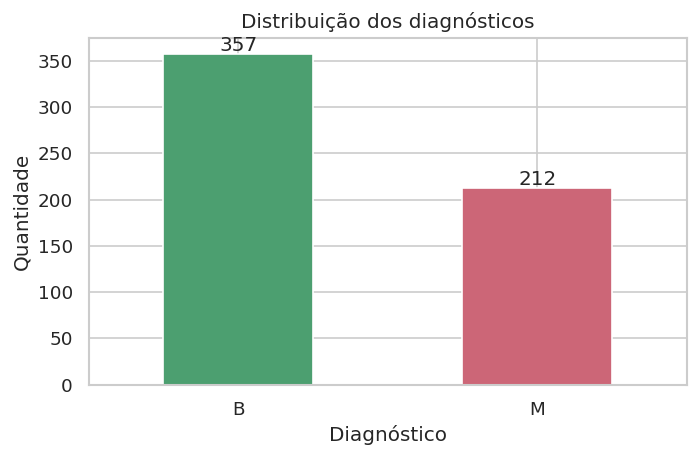

Há **357 casos benignos (62.7%)** e **212 malignos (37.3%)**. Como há mais benignos, a acurácia sozinha não conta toda a história. Também vou observar precision, recall e F1 da classe maligna.

In [5]:
contagem = dados["diagnosis"].value_counts().reindex(["B", "M"])
display(pd.DataFrame({"Quantidade": contagem,
                      "Porcentagem": (contagem / len(dados) * 100).round(2)}))
ax = contagem.plot.bar(color=["#4C9F70", "#CC6677"], rot=0, figsize=(6, 4))
ax.set(title="Distribuição dos diagnósticos", xlabel="Diagnóstico", ylabel="Quantidade")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()
display(Markdown(
    f"Há **{contagem['B']} casos benignos ({contagem['B']/len(dados):.1%})** e "
    f"**{contagem['M']} malignos ({contagem['M']/len(dados):.1%})**. "
    "Como há mais benignos, a acurácia sozinha não conta toda a história. "
    "Também vou observar precision, recall e F1 da classe maligna."
))

### Distribuições de algumas medidas
Os boxplots permitem comparar raio, textura e área entre as classes. As variáveis foram escolhidas por serem fáceis de interpretar; todos os 30 atributos serão usados no modelo.

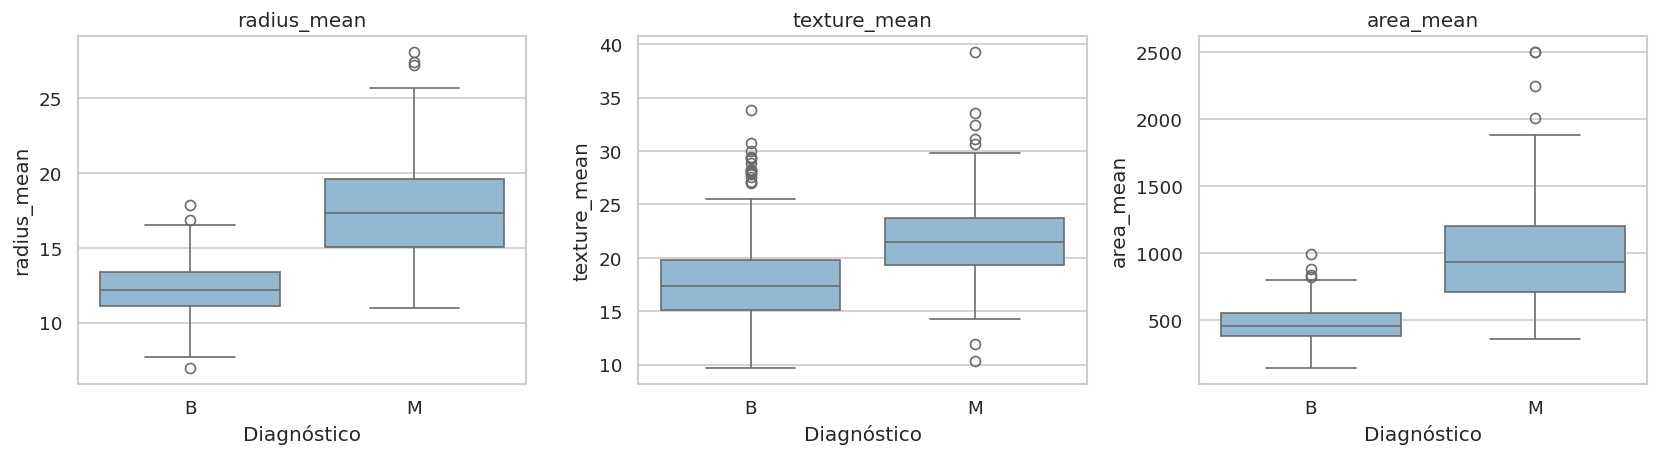

,radius_mean,texture_mean,area_mean
diagnosis,,,
B,12.200,17.39,458.4
M,17.325,21.46,932.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for coluna, ax in zip(["radius_mean", "texture_mean", "area_mean"], axes):
    sns.boxplot(data=dados, x="diagnosis", y=coluna, order=["B", "M"], ax=ax,
                color="#88BBDD")
    ax.set_title(coluna)
    ax.set_xlabel("Diagnóstico")
plt.tight_layout()
plt.show()
display(dados.groupby("diagnosis")[["radius_mean", "texture_mean", "area_mean"]].median())

Os casos malignos apresentaram medianas maiores: raio de 17,325 contra 12,200 e área de 932,0 contra 458,4 nos benignos. A textura também teve mediana maior nos malignos. Mesmo assim, os gráficos mostram sobreposição entre os grupos, então uma única medida não garante a separação dos diagnósticos.

### Correlação entre as medidas médias
O mapa abaixo mostra relações lineares entre as dez medidas médias. Correlação alta indica que duas medidas carregam informações parecidas, mas não significa uma relação de causa e efeito.

Correlação entre raio e perímetro: 0.998


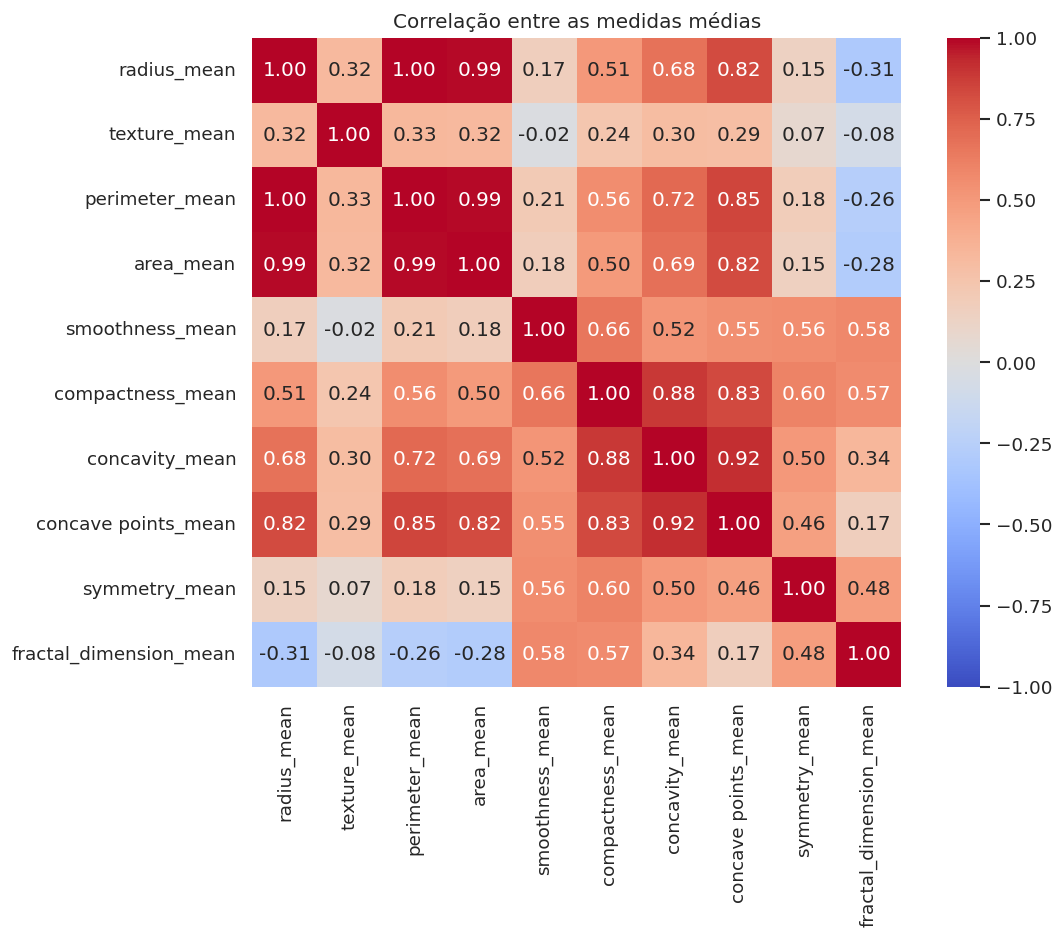

In [7]:
colunas_medias = [c for c in dados.columns if c.endswith("_mean")]
plt.figure(figsize=(10, 8))
sns.heatmap(dados[colunas_medias].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f", square=True)
plt.title("Correlação entre as medidas médias")
plt.tight_layout()
plt.show()
print("Correlação entre raio e perímetro:",
      round(dados["radius_mean"].corr(dados["perimeter_mean"]), 3))

Raio e perímetro representam aspectos relacionados ao tamanho, então faz sentido observar a correlação entre eles. Vou manter todos os atributos, pois a atividade está focada na comparação dos kernels e não em seleção de variáveis.

## 4. Limpeza e codificação
A coluna `id` é um identificador, então será removida. Também vou retirar as colunas totalmente vazias e conferir se sobrou algum valor ausente. A classe maligna será representada por **1** e a benigna por **0**.

In [8]:
dados_limpos = dados.drop(columns=["id"]).dropna(axis=1, how="all").copy()
print("Colunas removidas:", [c for c in dados.columns if c not in dados_limpos.columns])
print("Dimensões após a limpeza:", dados_limpos.shape)
display(dados_limpos.isna().sum().to_frame("Ausentes após limpeza"))
assert dados_limpos.isna().sum().sum() == 0, "Existem valores ausentes a tratar."
assert set(dados_limpos["diagnosis"].unique()) == {"B", "M"}

dados_limpos["diagnosis"] = dados_limpos["diagnosis"].map({"M": 1, "B": 0})
X = dados_limpos.drop(columns="diagnosis")
y = dados_limpos["diagnosis"]
print("Características:", X.shape)
print("Alvo:", y.shape)
display(y.value_counts().sort_index().rename_axis("diagnosis").to_frame("Quantidade"))

Colunas removidas: ['id', 'Unnamed: 32']
Dimensões após a limpeza: (569, 31)
Características: (569, 30)
Alvo: (569,)


,Ausentes após limpeza
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


,Quantidade
diagnosis,
0,357
1,212


A verificação acima confirma se a base ficou sem valores ausentes. Não vou preencher a coluna totalmente vazia, porque ela não traz informação. Também não vou excluir valores extremos só por aparecerem nos boxplots, pois podem ser medidas válidas.

## 5. Separação entre treino e teste
Vou reservar 80% para treinamento e 20% para teste. O `random_state=42` permite reproduzir a divisão e `stratify=y` mantém aproximadamente a proporção das classes. O conjunto de teste não será usado para ajustar os parâmetros.

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)
display(pd.DataFrame({
    "Total": y.value_counts().sort_index(),
    "Treino": y_treino.value_counts().sort_index(),
    "Teste": y_teste.value_counts().sort_index()
}).rename(index={0: "Benigno", 1: "Maligno"}))

Treino: (455, 30) | Teste: (114, 30)


,Total,Treino,Teste
diagnosis,,,
Benigno,357,285,72
Maligno,212,170,42


## 6. Padronização sem vazamento de dados
O SVM é sensível à escala das variáveis. Uma medida como área pode ter valores muito maiores que suavidade e acabar tendo influência excessiva. O `StandardScaler` subtrai a média e divide pelo desvio padrão de cada atributo, usando as estatísticas do treino. Isso não torna a distribuição necessariamente normal.

Segundo a [documentação do StandardScaler, do scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), atributos com variância muito maior podem dominar a função objetivo, incluindo o kernel RBF do SVM.

Para deixar a operação clara, abaixo uso `fit` somente no treino e `transform` no treino e no teste. Esses arrays servem para demonstrar a padronização. **Na busca de parâmetros, vou passar os dados originais a um Pipeline**, que refaz o ajuste do scaler somente na parte de treino de cada divisão da validação cruzada. Assim, nem a validação nem o teste vazam para o ajuste.

In [10]:
scaler = StandardScaler()
scaler.fit(X_treino)
X_treino_padronizado = scaler.transform(X_treino)
X_teste_padronizado = scaler.transform(X_teste)

display(pd.DataFrame({
    "Média no treino após padronização": X_treino_padronizado.mean(axis=0),
    "Desvio padrão no treino após padronização": X_treino_padronizado.std(axis=0)
}, index=X.columns).head().round(6))
print("Amostras usadas no fit do scaler:", scaler.n_samples_seen_)

Amostras usadas no fit do scaler: 455.0


,Média no treino após padronização,Desvio padrão no treino após padronização
radius_mean,-0.0,1.0
texture_mean,0.0,1.0
perimeter_mean,0.0,1.0
area_mean,-0.0,1.0
smoothness_mean,0.0,1.0


As médias do treino ficam próximas de zero e os desvios próximos de um. O teste não precisa apresentar exatamente esses valores, pois foi transformado com as estatísticas do treino, sem um novo ajuste.

## 7. Validação cruzada e escolha dos parâmetros
Vou usar cinco divisões estratificadas no treinamento. O critério de seleção será o **F1 da classe maligna**, definido antes da avaliação final. Ele combina precision e recall; o recall também será analisado separadamente por representar quantos malignos foram encontrados.

- **C:** controla a penalização dos erros. Valores menores aplicam mais regularização; valores maiores penalizam mais os erros de treinamento e podem favorecer sobreajuste.
- **Gamma:** no RBF, controla o alcance da influência de cada amostra. Valores altos deixam a fronteira mais local e podem sobreajustar; valores baixos deixam a fronteira mais suave.

O kernel linear busca uma fronteira linear no espaço dos atributos. O RBF permite fronteiras não lineares. `gamma` não é ajustado no linear porque não tem efeito nesse kernel.

O Pipeline junta as etapas: primeiro o scaler e depois o SVM. Com `refit=True`, a melhor combinação é novamente ajustada em todo o conjunto de treino, sem usar o teste.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
valores_C = [0.1, 1, 10, 100]
valores_gamma = ["scale", "auto", 0.001, 0.01, 0.1, 1]

### 7.1. SVM linear
Vou comparar os quatro valores de C. A tabela mostra o F1 médio na validação, sua variação entre as divisões e o resultado no treino.

In [12]:
pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])
busca_linear = GridSearchCV(
    pipeline_linear, {"svm__C": valores_C},
    scoring="f1", cv=cv, refit=True, return_train_score=True, n_jobs=1
)
busca_linear.fit(X_treino, y_treino)
resultados_linear = pd.DataFrame(busca_linear.cv_results_)
display(resultados_linear[["param_svm__C", "mean_train_score",
                           "mean_test_score", "std_test_score", "rank_test_score"]]
        .sort_values("rank_test_score").round(4))
print("Melhores parâmetros:", busca_linear.best_params_)
print("Melhor F1 médio na validação:", round(busca_linear.best_score_, 4))

Melhores parâmetros: {'svm__C': 0.1}
Melhor F1 médio na validação: 0.9548


,param_svm__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.1,0.9746,0.9548,0.0103,1
1,1.0,0.9851,0.9523,0.0159,2
2,10.0,0.9919,0.9472,0.0217,3
3,100.0,1.0000,0.9471,0.0150,4


In [13]:
display(Markdown(
    f"O melhor C do linear foi **{busca_linear.best_params_['svm__C']}**, "
    f"com F1 médio de **{busca_linear.best_score_:.4f}** na validação. "
    "O nome `mean_test_score` nessa tabela significa a pontuação das divisões "
    "de validação do GridSearchCV, e não do conjunto de teste reservado."
))

O melhor C do linear foi **0.1**, com F1 médio de **0.9548** na validação. O nome `mean_test_score` nessa tabela significa a pontuação das divisões de validação do GridSearchCV, e não do conjunto de teste reservado.

### 7.2. SVM RBF
Agora vou testar as 24 combinações de C e gamma, usando as mesmas divisões e o mesmo critério do modelo linear.

In [14]:
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])
busca_rbf = GridSearchCV(
    pipeline_rbf, {"svm__C": valores_C, "svm__gamma": valores_gamma},
    scoring="f1", cv=cv, refit=True, return_train_score=True, n_jobs=1
)
busca_rbf.fit(X_treino, y_treino)
resultados_rbf = pd.DataFrame(busca_rbf.cv_results_)
display(resultados_rbf[["param_svm__C", "param_svm__gamma", "mean_train_score",
                       "mean_test_score", "std_test_score", "rank_test_score"]]
        .sort_values("rank_test_score").round(4))
print("Melhores parâmetros:", busca_rbf.best_params_)
print("Melhor F1 médio na validação:", round(busca_rbf.best_score_, 4))

Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 'scale'}
Melhor F1 médio na validação: 0.9674


,param_svm__C,param_svm__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
12,10.0,scale,0.9873,0.9674,0.0114,1
13,10.0,auto,0.9873,0.9674,0.0114,1
15,10.0,0.01,0.9813,0.9669,0.0157,3
20,100.0,0.001,0.9790,0.9640,0.0161,4
7,1.0,auto,0.9813,0.9610,0.0082,5
6,1.0,scale,0.9813,0.9610,0.0082,5
21,100.0,0.01,0.9933,0.9588,0.0109,7
19,100.0,auto,1.0000,0.9532,0.0112,8
18,100.0,scale,1.0000,0.9532,0.0112,8
9,1.0,0.01,0.9690,0.9510,0.0123,10


### Efeito de C e gamma na validação
O gráfico permite comparar as combinações sem consultar o conjunto de teste. Um resultado alto no treino e mais baixo na validação pode indicar sobreajuste.

Modelo selecionado antes de consultar o teste: SVM RBF


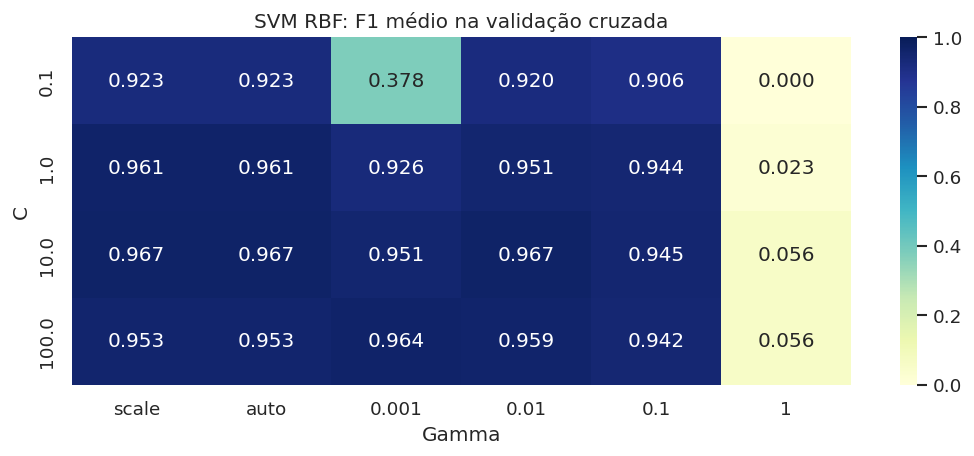

,Melhor F1 na validação
Modelo,
SVM linear,0.9548
SVM RBF,0.9674


In [15]:
tabela_gamma = resultados_rbf.copy()
tabela_gamma["gamma"] = tabela_gamma["param_svm__gamma"].astype(str)
mapa = tabela_gamma.pivot(index="param_svm__C", columns="gamma", values="mean_test_score")
mapa = mapa.reindex(columns=[str(g) for g in valores_gamma])
plt.figure(figsize=(9, 4))
sns.heatmap(mapa, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("SVM RBF: F1 médio na validação cruzada")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.tight_layout()
plt.show()

comparacao_cv = pd.DataFrame({
    "Modelo": ["SVM linear", "SVM RBF"],
    "Melhor F1 na validação": [busca_linear.best_score_, busca_rbf.best_score_]
}).set_index("Modelo")
display(comparacao_cv.round(4))
escolhido_cv = comparacao_cv["Melhor F1 na validação"].idxmax()
print("Modelo selecionado antes de consultar o teste:", escolhido_cv)

In [16]:
display(Markdown(
    f"No RBF, a combinação selecionada foi **C={busca_rbf.best_params_['svm__C']}** "
    f"e **gamma={busca_rbf.best_params_['svm__gamma']}**, com F1 médio "
    f"de **{busca_rbf.best_score_:.4f}**. O modelo escolhido pela validação foi "
    f"**{escolhido_cv}**. A comparação mostra que aumentar C ou gamma "
    "não garante melhorar o resultado. `scale` e `auto` podem ter resultados "
    "iguais ou muito próximos depois da padronização, pois passam a produzir "
    "valores de gamma semelhantes."
))

No RBF, a combinação selecionada foi **C=10** e **gamma=scale**, com F1 médio de **0.9674**. O modelo escolhido pela validação foi **SVM RBF**. A comparação mostra que aumentar C ou gamma não garante melhorar o resultado. `scale` e `auto` podem ter resultados iguais ou muito próximos depois da padronização, pois passam a produzir valores de gamma semelhantes.

## 8. Avaliação no conjunto de teste
**Interpretação da busca:** no linear, aumentar C de 0,1 para 100 elevou o F1 de treino de 0,9746 para 1,0000, mas reduziu o F1 médio de validação de 0,9548 para 0,9471. Isso mostra que acertar mais no treino não garante melhor generalização. No RBF, C=10 e gamma=scale/auto empataram com F1 médio de 0,9674; o GridSearchCV retornou scale, a primeira opção empatada. Com gamma=1 e C=10, o F1 de treino foi 1,0000, mas o de validação ficou em 0,0559, um sinal forte de sobreajuste.

Os parâmetros já estão definidos. Agora vou avaliar os dois modelos nos mesmos dados de teste, sem fazer novos ajustes a partir desses resultados.

- **Accuracy:** proporção total de acertos.
- **Precision:** entre as previsões malignas, quantas realmente eram malignas.
- **Recall:** entre os casos malignos reais, quantos foram identificados.
- **F1-score:** média harmônica de precision e recall.

Na tabela principal, precision, recall e F1 usam **maligno = 1** como classe positiva. O classification report apresenta também os resultados de benignos, as médias e o suporte de cada classe. Nas matrizes, as linhas são as classes reais e as colunas são as previstas.


 SVM linear
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114


 SVM RBF
              precision    recall  f1-score   support

 Benigno (0)     0.9600    1.0000    0.9796        72
 Maligno (1)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



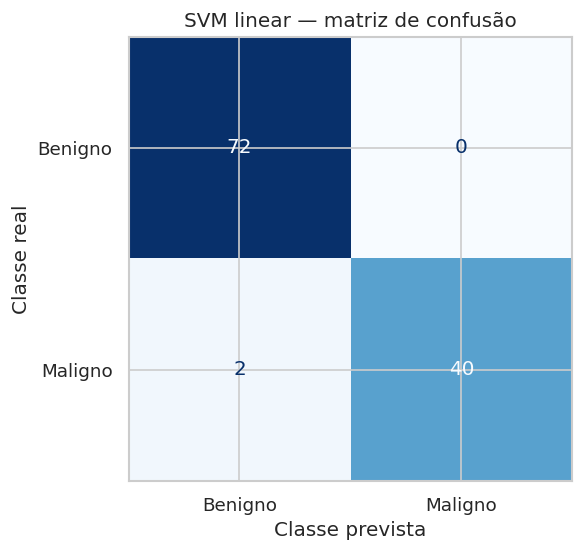

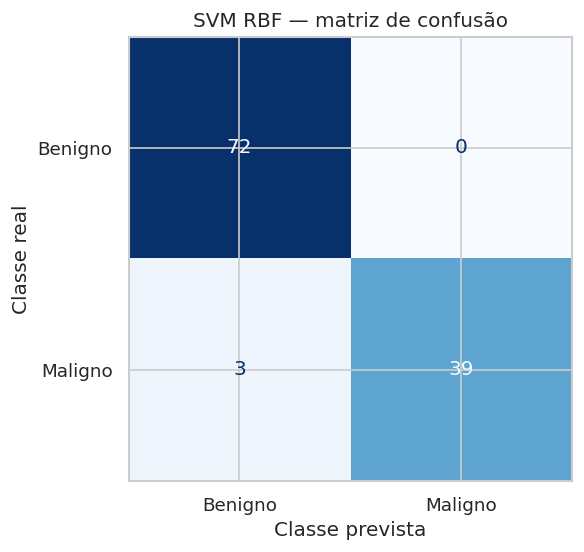

,Accuracy,Precision,Recall,F1-score
Modelo,,,,
SVM linear,0.9825,1.0,0.9524,0.9756
SVM RBF,0.9737,1.0,0.9286,0.9630


In [17]:
modelos = {"SVM linear": busca_linear.best_estimator_,
           "SVM RBF": busca_rbf.best_estimator_}
linhas = []
matrizes = {}
for nome, modelo in modelos.items():
    previsao = modelo.predict(X_teste)
    linhas.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, previsao),
        "Precision": precision_score(y_teste, previsao, zero_division=0),
        "Recall": recall_score(y_teste, previsao, zero_division=0),
        "F1-score": f1_score(y_teste, previsao, zero_division=0)
    })
    matrizes[nome] = confusion_matrix(y_teste, previsao, labels=[0, 1])
    print("\n", nome)
    print(classification_report(y_teste, previsao, labels=[0, 1],
          target_names=["Benigno (0)", "Maligno (1)"], digits=4, zero_division=0))
    ConfusionMatrixDisplay(matrizes[nome], display_labels=["Benigno", "Maligno"]).plot(
        cmap="Blues", colorbar=False)
    plt.title(nome + " — matriz de confusão")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.tight_layout()
    plt.show()

comparacao = pd.DataFrame(linhas).set_index("Modelo")
display(comparacao.round(4))

## 9. Comparação dos modelos
A comparação a seguir descreve o teste final. Ela não será usada para repetir a busca de parâmetros. Além dos acertos, vou conferir os falsos negativos, que são os casos malignos classificados como benignos.

In [18]:
for nome in modelos:
    m = comparacao.loc[nome]
    tn, fp, fn, tp = matrizes[nome].ravel()
    display(Markdown(
        f"**{nome}:** accuracy de **{m['Accuracy']:.2%}**, precision de "
        f"**{m['Precision']:.2%}**, recall de **{m['Recall']:.2%}** e F1 de "
        f"**{m['F1-score']:.4f}**. A matriz mostra {tn} benignos e {tp} malignos "
        f"classificados corretamente, {fp} falsos positivos e {fn} falsos negativos."
    ))

diferenca = comparacao.loc["SVM RBF", "F1-score"] - comparacao.loc["SVM linear", "F1-score"]
if np.isclose(diferenca, 0):
    frase = "Os dois kernels tiveram o mesmo F1 neste conjunto de teste."
elif diferenca > 0:
    frase = f"O RBF teve F1 maior no teste, com diferença de {diferenca:.4f}."
else:
    frase = f"O linear teve F1 maior no teste, com diferença de {-diferenca:.4f}."
display(Markdown(frase + f" A escolha baseada apenas na validação continua sendo **{escolhido_cv}**."))

**SVM linear:** accuracy de **98.25%**, precision de **100.00%**, recall de **95.24%** e F1 de **0.9756**. A matriz mostra 72 benignos e 40 malignos classificados corretamente, 0 falsos positivos e 2 falsos negativos.

**SVM RBF:** accuracy de **97.37%**, precision de **100.00%**, recall de **92.86%** e F1 de **0.9630**. A matriz mostra 72 benignos e 39 malignos classificados corretamente, 0 falsos positivos e 3 falsos negativos.

O linear teve F1 maior no teste, com diferença de 0.0126. A escolha baseada apenas na validação continua sendo **SVM RBF**.

## 10. Conclusão
Nesta atividade, explorei a base, removi o identificador e as colunas vazias, codifiquei o diagnóstico e separei os dados em treino e teste. Depois comparei dois modelos SVM, com kernels linear e RBF, utilizando padronização e validação cruzada.

O resumo numérico abaixo é calculado a partir da execução, para manter a conclusão consistente com os resultados.

Nesta execução, o linear acertou 112 dos 114 casos e o RBF acertou 111. Ambos tiveram precision de 100% para malignos, mas isso não significa que encontraram todos eles: o linear deixou passar 2 e o RBF, 3. O recall foi de 95,24% e 92,86%, respectivamente. A diferença de um caso é pequena e não comprova superioridade geral de um kernel.

A validação favoreceu o RBF (F1 médio de 0,9674 contra 0,9548), enquanto o teste favoreceu o linear (F1 de 0,9756 contra 0,9630). Isso pode acontecer por variação da amostra. Mantive a seleção pela validação, sem reajustar os modelos depois de observar o teste.


In [19]:
l = comparacao.loc["SVM linear"]
r = comparacao.loc["SVM RBF"]
display(Markdown(
    f"O SVM linear alcançou **{l['Accuracy']:.2%} de acurácia** e "
    f"**{l['F1-score']:.4f} de F1**, enquanto o RBF alcançou "
    f"**{r['Accuracy']:.2%} de acurácia** e **{r['F1-score']:.4f} de F1**. "
    f"{frase} Na validação cruzada, o escolhido foi **{escolhido_cv}**. "
    f"O ajuste selecionou C={busca_linear.best_params_['svm__C']} para o linear "
    f"e C={busca_rbf.best_params_['svm__C']}, gamma={busca_rbf.best_params_['svm__gamma']} "
    "para o RBF. Esses valores são os melhores entre os que foram testados, "
    "não necessariamente os melhores possíveis."
))

O SVM linear alcançou **98.25% de acurácia** e **0.9756 de F1**, enquanto o RBF alcançou **97.37% de acurácia** e **0.9630 de F1**. O linear teve F1 maior no teste, com diferença de 0.0126. Na validação cruzada, o escolhido foi **SVM RBF**. O ajuste selecionou C=0.1 para o linear e C=10, gamma=scale para o RBF. Esses valores são os melhores entre os que foram testados, não necessariamente os melhores possíveis.

O linear utiliza uma fronteira mais simples, enquanto o RBF permite relações não lineares. A maior flexibilidade do RBF não garante vantagem em qualquer divisão dos dados. O ajuste de C equilibra regularização e penalização dos erros; no RBF, gamma também modifica a flexibilidade da fronteira. As tabelas de validação ajudam a observar esse efeito sem ajustar o modelo ao teste.

A padronização foi importante porque os atributos têm escalas diferentes. O scaler foi ajustado apenas no treinamento, inclusive dentro de cada divisão da validação cruzada. Não foi feito um experimento sem padronização, então não dá para atribuir uma melhoria numérica específica a essa etapa.

**Limitações:** a base é pequena e o teste representa apenas uma divisão com 114 registros. Outra separação pode mudar os resultados. A grade de parâmetros foi limitada e não foi utilizada uma base externa de outro hospital ou população. Além disso, o melhor resultado da validação foi usado na seleção, então pode ser otimista. Esses resultados servem para estudar o método e não demonstram que o modelo esteja pronto para uso clínico.

## 11. Conferência final
A célula abaixo verifica os pontos principais do processamento. Os gráficos, relatórios e explicações estão nas seções anteriores.

In [20]:
assert X.shape == (569, 30)
assert "id" not in X.columns and "diagnosis" not in X.columns
assert not X.isna().any().any()
assert set(y.unique()) == {0, 1}
assert len(X_treino) == 455 and len(X_teste) == 114
assert set(X_treino.index).isdisjoint(X_teste.index)
for nome, modelo in modelos.items():
    assert isinstance(modelo.named_steps["svm"], SVC)
    assert modelo.named_steps["scaler"].n_samples_seen_ == len(X_treino)
    assert np.allclose(modelo.named_steps["scaler"].mean_, X_treino.mean())
    assert matrizes[nome].sum() == len(X_teste)
assert busca_linear.best_estimator_.named_steps["svm"].kernel == "linear"
assert busca_rbf.best_estimator_.named_steps["svm"].kernel == "rbf"
assert len(resultados_linear) == 4 and len(resultados_rbf) == 24
assert comparacao.notna().all().all()
print("Conferência concluída: dados, divisão, scaler, kernels, grades e métricas verificados.")

Conferência concluída: dados, divisão, scaler, kernels, grades e métricas verificados.


## Referências
- UCI Machine Learning / Kaggle. [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data). Fonte do arquivo `data.csv`.
- Scikit-learn. [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Fundamentação sobre padronização e sensibilidade à escala.
- Scikit-learn. [Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html). Kernels e parâmetros do SVM.
- Scikit-learn. [Common pitfalls: data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage). Separação de treino e teste e uso de Pipeline.